In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def plot_top_diff_per_area(
    df,
    year,
    land_type,
    top_n=10,
    outdir="figs"
):

    # -------- 筛选 --------
    d = df[(df["year"] == year) & (df["type"] == land_type)].copy()

    d["diff_per_area"] = d["diff/area"]

    # -------- 正负分组 --------
    pos = d[d["diff_per_area"] > 0].copy()
    neg = d[d["diff_per_area"] < 0].copy()

    pos = pos.sort_values("diff_per_area", ascending=False).head(top_n)
    neg = neg.sort_values("diff_per_area", ascending=True).head(top_n)

    plot_df = pd.concat([neg, pos])

    # 排序保证从负到正
    plot_df = plot_df.sort_values("diff_per_area")

    # -------- 作图 --------
    fig, ax = plt.subplots(figsize=(4, 4))

    colors = plot_df["diff_per_area"].apply(
        lambda x: "blue" if x > 0 else "red"
    )

    ax.barh(
        plot_df["region_name"],
        plot_df["diff_per_area"],
        color=colors
    )

    ax.axvline(0, color="black", linewidth=1)

    ax.set_title(
        f"Top 20 Regions with Absolute Changes in {land_type} \n Year: {year}",
        fontsize=12
    )
    ax.set_xlabel("Absolute Change per Area")
    ax.set_ylabel("Basin")
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()

    # -------- 保存 --------

    fname = f"{outdir}/{land_type}_{year}.png"
    plt.savefig(fname, dpi=300)
    print(f"Saved: {fname}")


Saved: ../../plot/absolutediff/nc-nc/FRS_2005.png
Saved: ../../plot/absolutediff/nc-nc/GL_2005.png
Saved: ../../plot/absolutediff/nc-nc/CL_2005.png
Saved: ../../plot/absolutediff/nc-nc/FRS_2050.png
Saved: ../../plot/absolutediff/nc-nc/GL_2050.png
Saved: ../../plot/absolutediff/nc-nc/CL_2050.png
Saved: ../../plot/absolutediff/nc-nc/FRS_2100.png
Saved: ../../plot/absolutediff/nc-nc/GL_2100.png
Saved: ../../plot/absolutediff/nc-nc/CL_2100.png


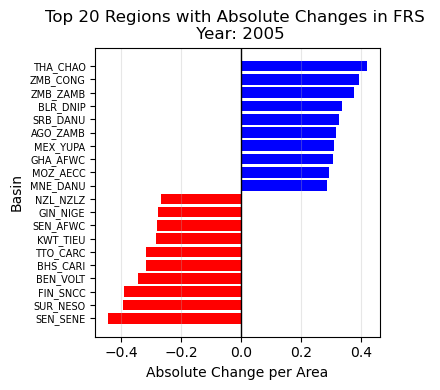

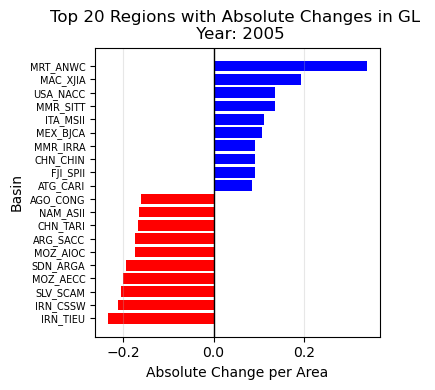

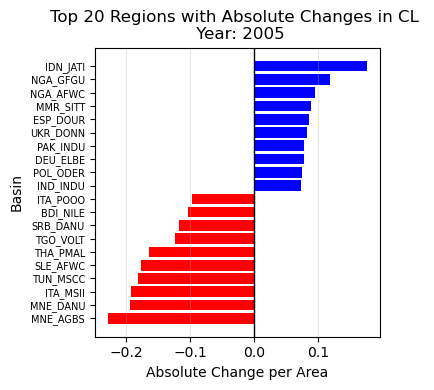

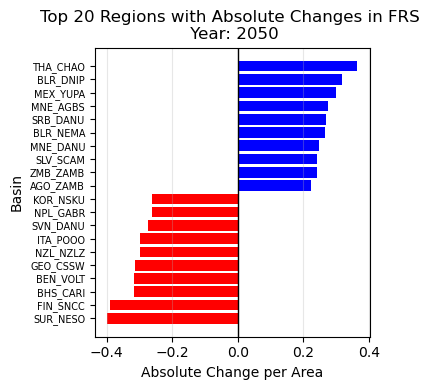

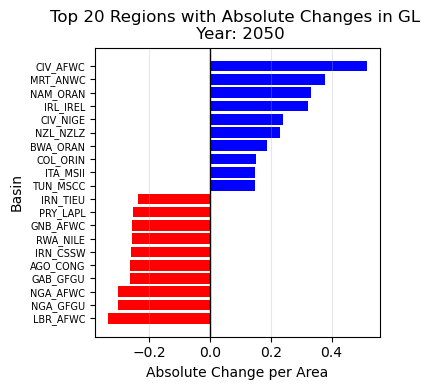

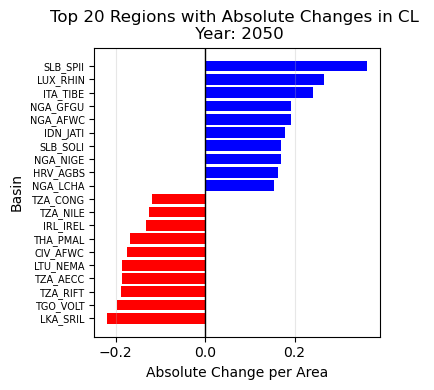

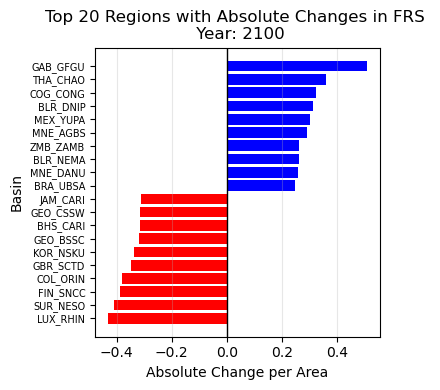

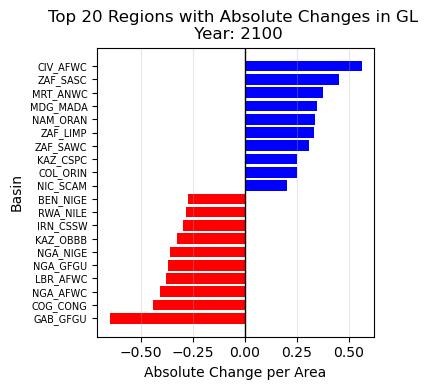

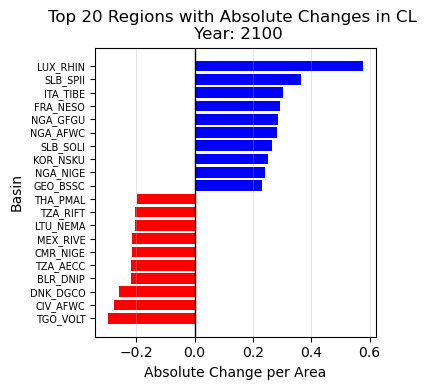

In [6]:
years = [2005, 2050, 2100]
types = ["FRS", "GL", "CL"]

df_diff = pd.read_csv("../../CSV/compare_region_basin/region_basin_diff(nc-nc).csv")

for y in years:
    for t in types:
        plot_top_diff_per_area(
            df=df_diff,
            year=y,
            land_type=t,
            top_n=10,
            outdir="../../plot/absolutediff/nc-nc"
        )
